# Amazon Prime TV Shows & Movies — Merged EDA + Machine Learning
**Project Type:** Exploratory Data Analysis + Regression  
**Dataset:** `titles.csv` merged with `credits.csv` on `id` 
**Objective:** Explore the Amazon Prime catalog and build a regression model to predict 
**IMDb score** from title metadata and aggregated credit information.

## Project Summary

This project analyzes an Amazon Prime catalog containing title-level metadata and person-level credits. The `titles` data contains information such as title, type, release year, age certification, runtime, genres, production countries, seasons, IMDb score/votes, and TMDB metrics. The `credits` data identifies people associated with each title and distinguishes actors from directors.

The first stage is data understanding and cleaning. The two files are merged using the common `id` field. Credit-level records are aggregated to title level so that the machine-learning dataset has one row per movie/show. Additional features such as actor count, director count, total credited people, and actor/director ratio are created. List-like genre and country columns are converted into useful categorical features.

The EDA section contains a large collection of visualizations covering catalog composition, release trends, runtimes, seasons, age certifications, genres, countries, IMDb/TMDB relationships, popularity, votes, and credit structure. Correlation analysis and pair plots are also included. The purpose is not only to produce charts but also to connect each visualization with a concrete analytical question.

For machine learning, the IMDb score is treated as the regression target. Rows without an IMDb score are excluded from model training because a supervised regression target is required. Numerical variables are median-imputed, and categorical variables are most-frequent-imputed and one-hot encoded. Four regression approaches are compared: Ridge Regression, Random Forest Regressor, Gradient Boosting Regressor, and xgboost Regressor. Cross-validation and hyperparameter tuning are used to improve the candidate models.

The final section compares MAE, RMSE, and R², inspects residuals, examines permutation importance, and performs a prediction sanity check on unseen records. The notebook is intentionally structured so that it can be rerun when the source CSV files are replaced with newer versions.

# **GitHub Link -** https://github.com/rahulg2527-source/-Amazon-Prime-TV-Shows-Movies-Merged-EDA-Mac.git

## Problem Statement

Streaming platforms contain thousands of movies and TV shows with different genres, release years, runtimes, certifications, popularity measures, and cast/director structures. A useful analytical system should identify patterns in the catalog and determine whether these attributes contain enough information to estimate a title's IMDb score.

### Business Objective

1. Understand the composition and evolution of the catalog.
2. Identify characteristics associated with higher/lower IMDb ratings.
3. Quantify relationships among IMDb score, TMDB score, popularity, votes, runtime and credits.
4. Build a reproducible regression model that estimates IMDb score for titles with known metadata.
5. Explain which engineered features contribute most to model predictions.

## 1. Know The Data

In [1]:

# Core imports
import ast
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

In [2]:
# Dataset loading
titles_path = "titles(2).csv"
credits_path = "credits(2).csv"

try:
    titles = pd.read_csv("/kaggle/input/datasets/sonug2527/titles/titles.csv")
    credits = pd.read_csv("/kaggle/input/datasets/sonug2527/credits/credits.csv")
except FileNotFoundError:
    # Convenient fallback when the notebook is moved next to the standard filenames
    titles = pd.read_csv("/kaggle/input/datasets/sonug2527/titles/titles.csv")
    credits = pd.read_csv("/kaggle/input/datasets/sonug2527/credits/credits.csv")

print("Titles shape:", titles.shape)
print("Credits shape:", credits.shape)

Titles shape: (9871, 15)
Credits shape: (124235, 5)


In [3]:
display(titles.head())
display(credits.head())


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,"The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 ...",1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal engineer Johnnie Gray's beloved locomotive, 'The General'—with Johnnie...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy', 'european']",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of every GI: the dream of the day when he will finally return home. For three...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper editor Walter Burns, visits his office to inform him that she's engag...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her temperamental boyfriend is a murderer.,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [4]:
print("Titles rows × columns:", titles.shape)
print("Credits rows × columns:", credits.shape)
print("Unique title IDs:", titles["id"].nunique())
print("Unique credit title IDs:", credits["id"].nunique())
print("Title IDs appearing in both files:", len(set(titles["id"]) & set(credits["id"])))

Titles rows × columns: (9871, 15)
Credits rows × columns: (124235, 5)
Unique title IDs: 9868
Unique credit title IDs: 8861
Title IDs appearing in both files: 8861


In [5]:
print("TITLE DATA TYPES")
display(titles.dtypes.to_frame("dtype"))

print("\nCREDIT DATA TYPES")
display(credits.dtypes.to_frame("dtype"))

TITLE DATA TYPES


,dtype
id,object
title,object
type,object
description,object
release_year,int64
age_certification,object
runtime,int64
genres,object
production_countries,object
seasons,float64



CREDIT DATA TYPES


,dtype
person_id,int64
id,object
name,object
character,object
role,object


In [6]:
print("Duplicate title rows:", titles.duplicated().sum())
print("Duplicate title IDs:", titles["id"].duplicated().sum())
print("Duplicate credit rows:", credits.duplicated().sum())

print("\nMissing values in titles:")
display(titles.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nMissing values in credits:")
display(credits.isna().sum().sort_values(ascending=False).to_frame("missing"))


Duplicate title rows: 3
Duplicate title IDs: 3
Duplicate credit rows: 56

Missing values in titles:


,missing
seasons,8514
age_certification,6487
tmdb_score,2082
imdb_votes,1031
imdb_score,1021
imdb_id,667
tmdb_popularity,547
description,119
runtime,0
title,0



Missing values in credits:


,missing
character,16287
person_id,0
id,0
name,0
role,0


### Initial observations

The title table is already at approximately one row per title, while the credits table is at person-title level. Therefore, a direct merge would create multiple rows per title. For machine learning and most title-level EDA, credits must first be aggregated to title level and then merged.

The model target is `imdb_score`, so rows where that value is missing will be excluded only from supervised training—not from the general EDA.


## 2. Understanding Variables

In [7]:
variable_summary = pd.DataFrame({
    "dtype": titles.dtypes.astype(str),
    "missing": titles.isna().sum(),
    "missing_%": (titles.isna().mean()*100).round(2),
    "unique": titles.nunique()
}).sort_values("missing_%", ascending=False)

display(variable_summary)


,dtype,missing,missing_%,unique
seasons,float64,8514,86.25,32
age_certification,object,6487,65.72,11
tmdb_score,float64,2082,21.09,89
imdb_votes,float64,1031,10.44,3650
imdb_score,float64,1021,10.34,86
imdb_id,object,667,6.76,9201
tmdb_popularity,float64,547,5.54,5325
description,object,119,1.21,9734
runtime,int64,0,0.00,207
title,object,0,0.00,9737


In [8]:
for col in ["type", "age_certification"]:
    print(f"\nUnique values — {col}")
    print(titles[col].value_counts(dropna=False).head(20))

print("\nCredit roles:")
display(credits["role"].value_counts(dropna=False).to_frame("count"))



Unique values — type
type
MOVIE    8514
SHOW     1357
Name: count, dtype: int64

Unique values — age_certification
age_certification
NaN      6487
R        1249
PG-13     588
PG        582
G         269
TV-MA     217
TV-14     188
TV-PG      91
TV-Y       78
TV-G       57
TV-Y7      52
NC-17      13
Name: count, dtype: int64

Credit roles:


,count
role,
ACTOR,115846
DIRECTOR,8389


## 3. Data Wrangling & Merging

In [9]:
def parse_list(value):
    """Safely convert a string representation of a Python list into a list."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        result = ast.literal_eval(value)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

titles_clean = titles.copy()
for col in ["genres", "production_countries"]:
    titles_clean[col + "_list"] = titles_clean[col].apply(parse_list)

# Aggregate credits from person-title grain to title grain.
credit_agg = credits.groupby("id").agg(
    total_credits=("person_id", "nunique"),
    actor_count=("person_id", lambda s: credits.loc[s.index].query("role == 'ACTOR'")["person_id"].nunique()),
    director_count=("person_id", lambda s: credits.loc[s.index].query("role == 'DIRECTOR'")["person_id"].nunique()),
    unique_people=("person_id", "nunique"),
).reset_index()

credit_agg["actor_director_ratio"] = (
    credit_agg["actor_count"] / credit_agg["director_count"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

df = titles_clean.merge(credit_agg, on="id", how="left")

for col in ["total_credits", "actor_count", "director_count", "unique_people"]:
    df[col] = df[col].fillna(0)

df["release_decade"] = (df["release_year"] // 10 * 10).astype("Int64")
df["vote_log"] = np.log1p(df["imdb_votes"])
df["popularity_log"] = np.log1p(df["tmdb_popularity"])

print("Merged dataset shape:", df.shape)
display(df.head(3))


Merged dataset shape: (9871, 25)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres_list,production_countries_list,total_credits,actor_count,director_count,unique_people,actor_director_ratio,release_decade,vote_log,popularity_log
0,ts20945,The Three Stooges,SHOW,"The Three Stooges were an American vaudeville and comedy team active from 1922 until 1970, best known for their 190 ...",1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,"[comedy, family, animation, action, fantasy, horror]",[US],3.0,3.0,0.0,3.0,NaN,1930,6.996681,2.798744
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal engineer Johnnie Gray's beloved locomotive, 'The General'—with Johnnie...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy', 'european']",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,"[action, drama, war, western, comedy, european]",[US],23.0,22.0,2.0,23.0,11.0,1920,11.404973,2.266647
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of every GI: the dream of the day when he will finally return home. For three...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8,"[romance, war, drama]",[US],31.0,30.0,1.0,31.0,30.0,1940,11.051318,2.244426


In [10]:
# Explode genres and countries for title-level analysis
genre_long = df[["id", "title", "type", "imdb_score", "genres_list"]].explode("genres_list").rename(columns={"genres_list":"genre"})
country_long = df[["id", "title", "type", "imdb_score", "production_countries_list"]].explode("production_countries_list").rename(columns={"production_countries_list":"country"})

genre_counts = genre_long["genre"].value_counts().dropna()
country_counts = country_long["country"].value_counts().dropna()

print("Top genres:")
display(genre_counts.head(15).to_frame("titles"))

print("Top countries:")
display(country_counts.head(15).to_frame("titles"))


Top genres:


,titles
genre,
drama,4764
comedy,2987
thriller,2119
action,1820
romance,1752
crime,1251
documentation,1096
horror,1065
family,751


Top countries:


,titles
country,
US,5334
IN,1072
GB,928
CA,530
FR,250
JP,197
AU,173
DE,172
CN,143


In [11]:
# Data quality snapshot after merging
quality = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "duplicate_ids": [df["id"].duplicated().sum()],
    "missing_imdb_score": [df["imdb_score"].isna().sum()],
    "missing_tmdb_score": [df["tmdb_score"].isna().sum()],
    "missing_description": [df["description"].isna().sum()],
    "credit_rows_before_aggregation": [len(credits)],
    "credit_title_ids": [credits["id"].nunique()]
})
display(quality)


,rows,columns,duplicate_ids,missing_imdb_score,missing_tmdb_score,missing_description,credit_rows_before_aggregation,credit_title_ids
0,9871,25,3,1021,2082,119,124235,8861


#### Chart 1 — Movies vs TV Shows

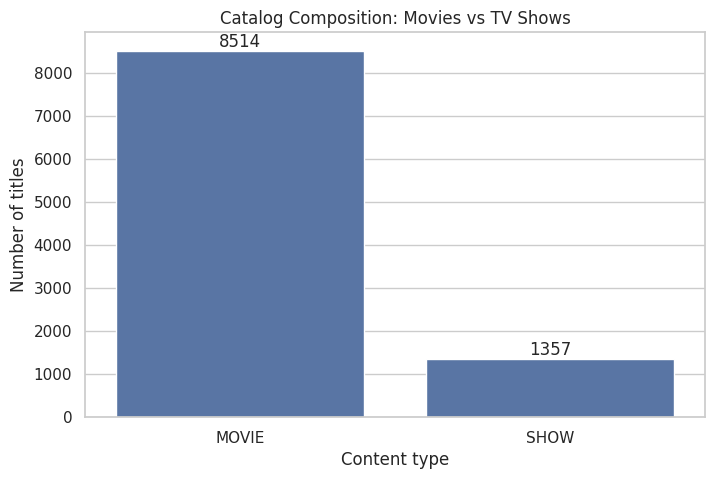

In [12]:
plt.figure(figsize=(8,5))
ax=sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Catalog Composition: Movies vs TV Shows")
plt.xlabel("Content type"); plt.ylabel("Number of titles")
for container in ax.containers: ax.bar_label(container)
plt.show()

**Why this chart?** A count plot is appropriate because the goal is to compare two categorical groups. The resulting split shows the catalog's basic composition.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

**Why this chart?** A line chart highlights the temporal evolution of the catalog. Peaks and declines can be used to identify periods with unusually high or low representation.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 2 — Releases by Decade

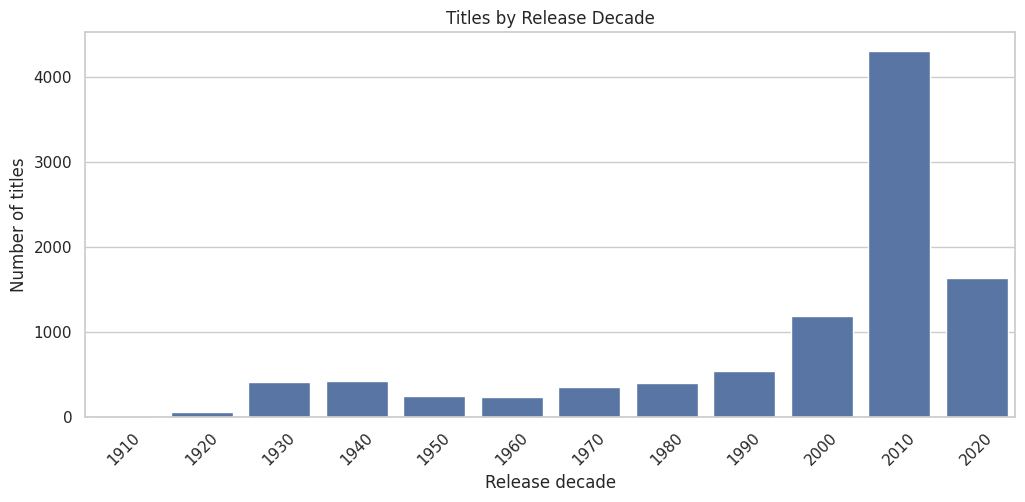

In [13]:
decade_counts=df["release_decade"].value_counts().sort_index()
plt.figure(figsize=(12,5))
ax=sns.barplot(x=decade_counts.index.astype(str), y=decade_counts.values)
plt.title("Titles by Release Decade")
plt.xlabel("Release decade"); plt.ylabel("Number of titles")
plt.xticks(rotation=45)
plt.show()

**Why this chart?** Decades reduce year-to-year noise and make the historical composition easier to compare.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 3 — Runtime Distribution

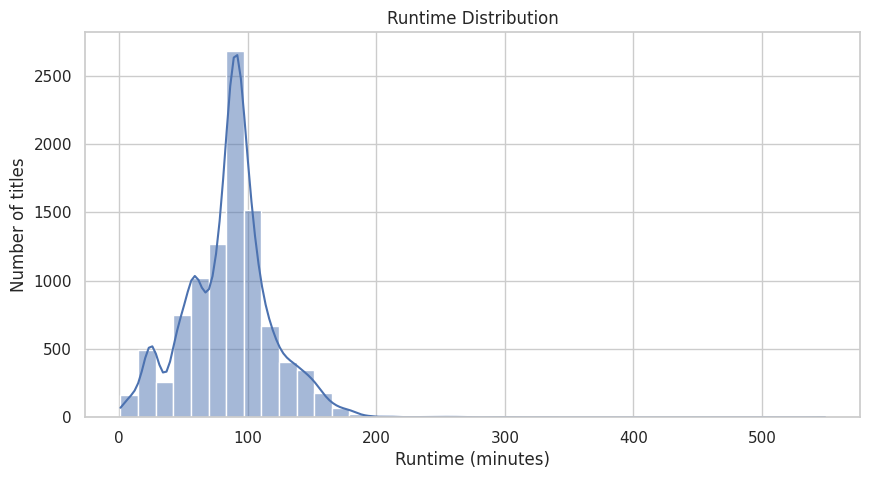

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["runtime"], bins=40, kde=True)
plt.title("Runtime Distribution")
plt.xlabel("Runtime (minutes)"); plt.ylabel("Number of titles")
plt.show()

**Why this chart?** A histogram shows the shape, center and long-tail behavior of runtime. This is useful for spotting unusually short or long titles.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 4 — Runtime by Content Type

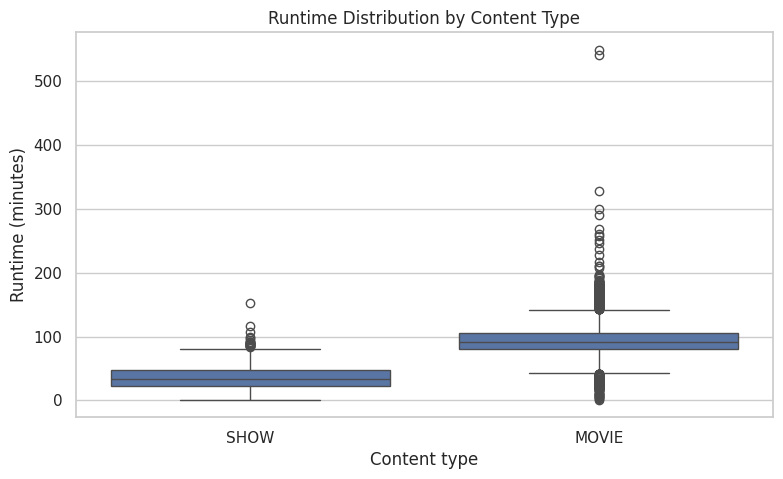

In [15]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="type", y="runtime")
plt.title("Runtime Distribution by Content Type")
plt.xlabel("Content type"); plt.ylabel("Runtime (minutes)")
plt.show()

**Why this chart?** Box plots compare medians, spread and outliers between movies and shows.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 5 — IMDb Score by Content Type

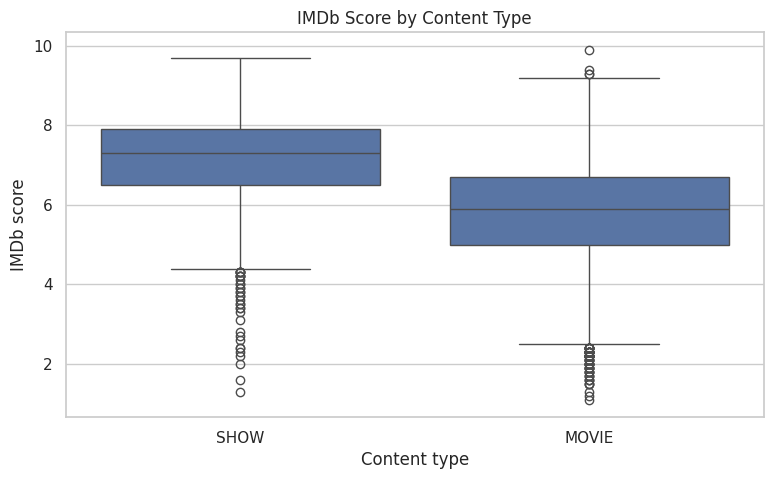

In [16]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="type", y="imdb_score")
plt.title("IMDb Score by Content Type")
plt.xlabel("Content type"); plt.ylabel("IMDb score")
plt.show()

**Why this chart?** This comparison checks whether the rating distribution differs between movies and shows.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 6 — Top Genres

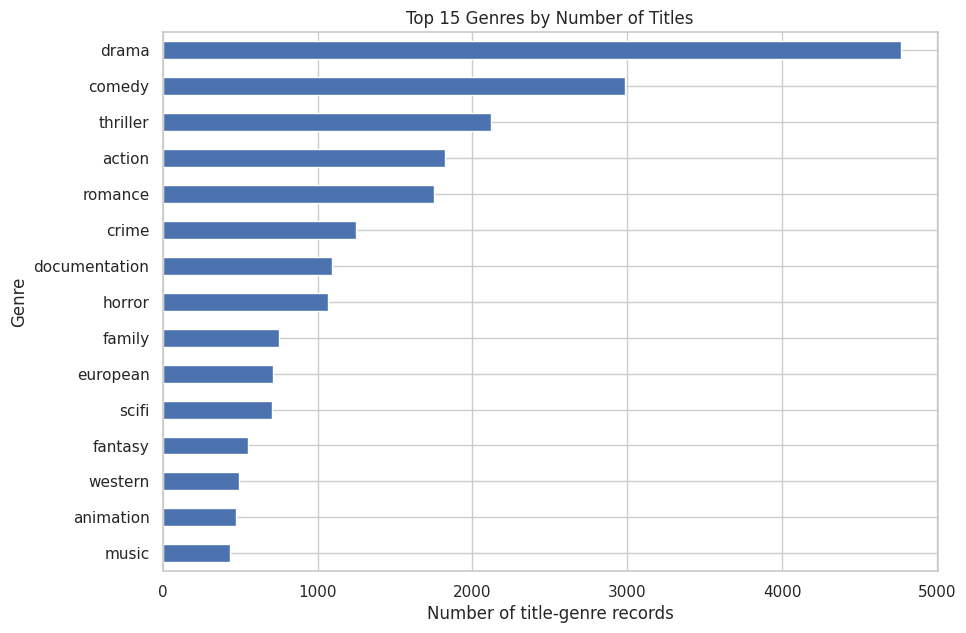

In [17]:
topg=genre_counts.head(15).sort_values()
plt.figure(figsize=(10,7))
ax=topg.plot(kind="barh")
plt.title("Top 15 Genres by Number of Titles")
plt.xlabel("Number of title-genre records"); plt.ylabel("Genre")
plt.show()

**Why this chart?** A horizontal bar chart handles many category labels clearly and identifies the most represented genres.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 7 — Top Production Countries

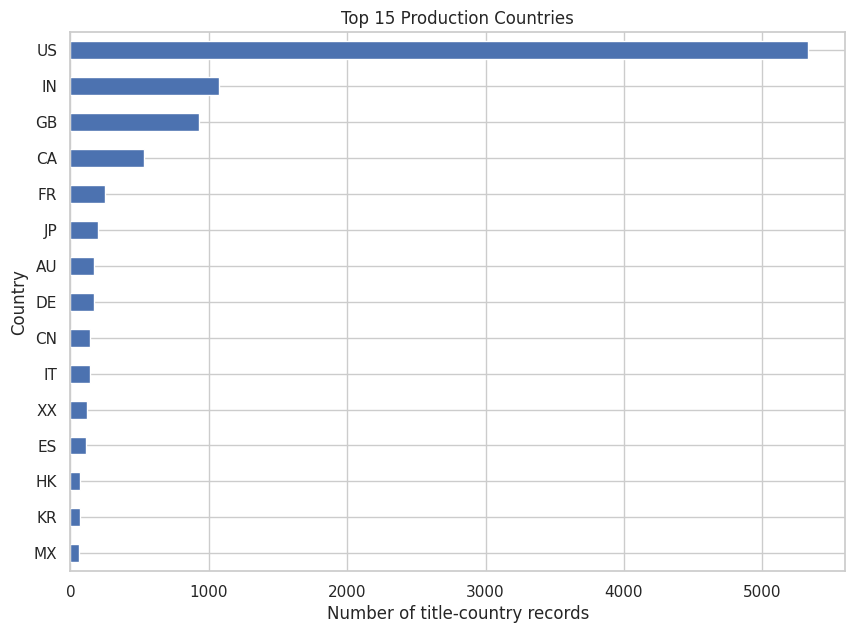

In [18]:
topc=country_counts.head(15).sort_values()
plt.figure(figsize=(10,7))
topc.plot(kind="barh")
plt.title("Top 15 Production Countries")
plt.xlabel("Number of title-country records"); plt.ylabel("Country")
plt.show()

#### Chart 08 — IMDb vs TMDB Score

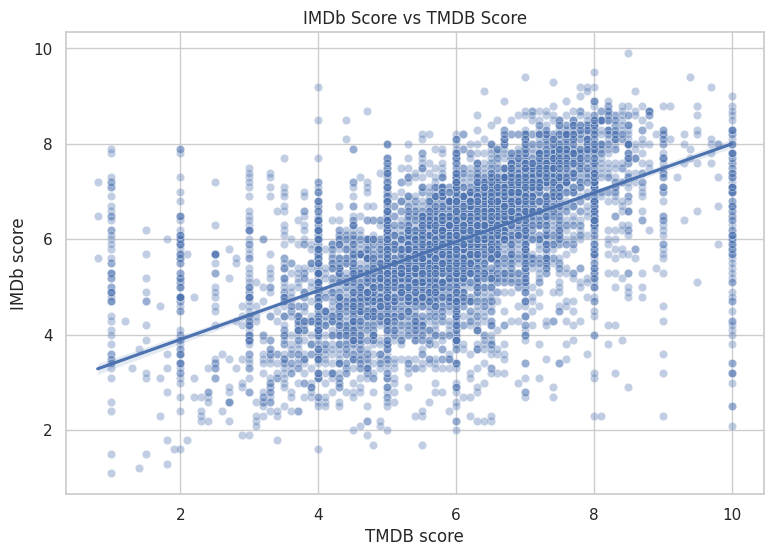

Pearson correlation: 0.5809682772679561


In [19]:
tmp=df.dropna(subset=["imdb_score","tmdb_score"])
plt.figure(figsize=(9,6))
sns.scatterplot(data=tmp, x="tmdb_score", y="imdb_score", alpha=0.35)
sns.regplot(data=tmp, x="tmdb_score", y="imdb_score", scatter=False)
plt.title("IMDb Score vs TMDB Score")
plt.xlabel("TMDB score"); plt.ylabel("IMDb score")
plt.show()
print("Pearson correlation:", tmp["tmdb_score"].corr(tmp["imdb_score"], method="pearson"))


**Why this chart?** A scatter plot directly examines the relationship between two continuous ratings. The fitted trend and correlation quantify whether the two platforms tend to agree.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 9 — Correlation Heatmap

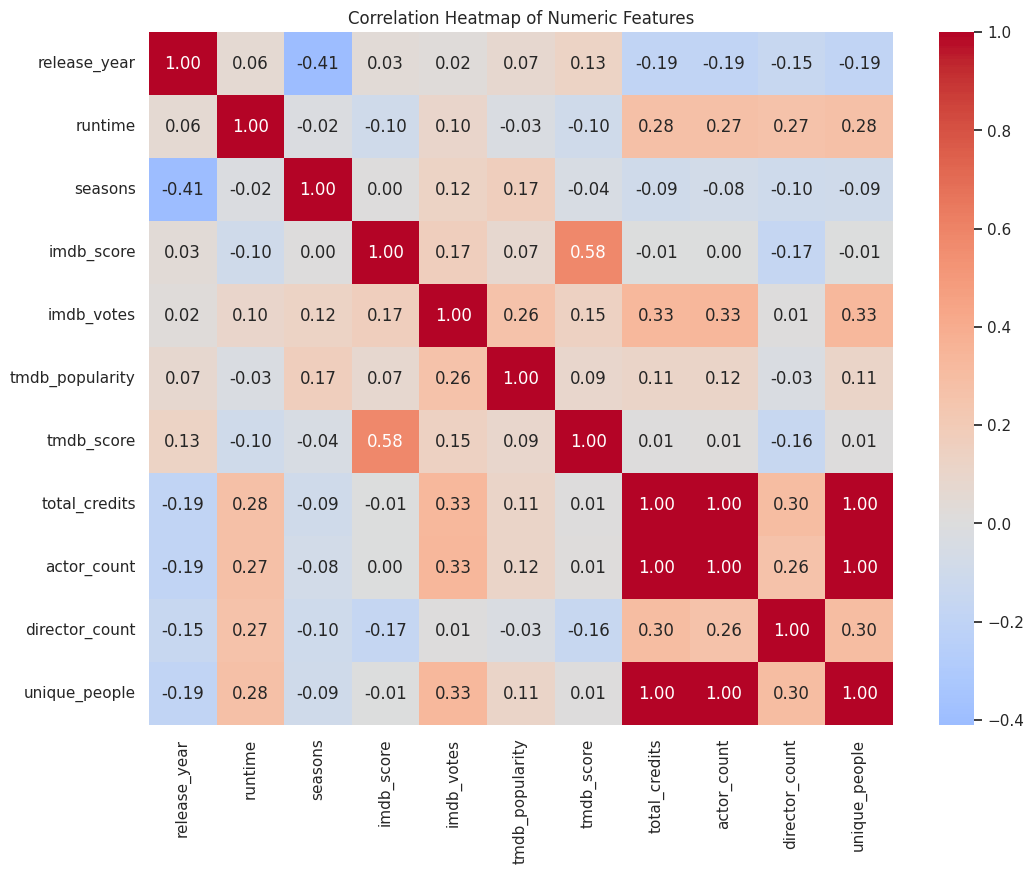

In [20]:
corr_cols=["release_year","runtime","seasons","imdb_score","imdb_votes","tmdb_popularity","tmdb_score",
           "total_credits","actor_count","director_count","unique_people"]
plt.figure(figsize=(12,9))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Why this chart?** A heatmap summarizes pairwise linear relationships and helps identify potential predictors and redundant features.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

#### Chart 10 — Pair Plot

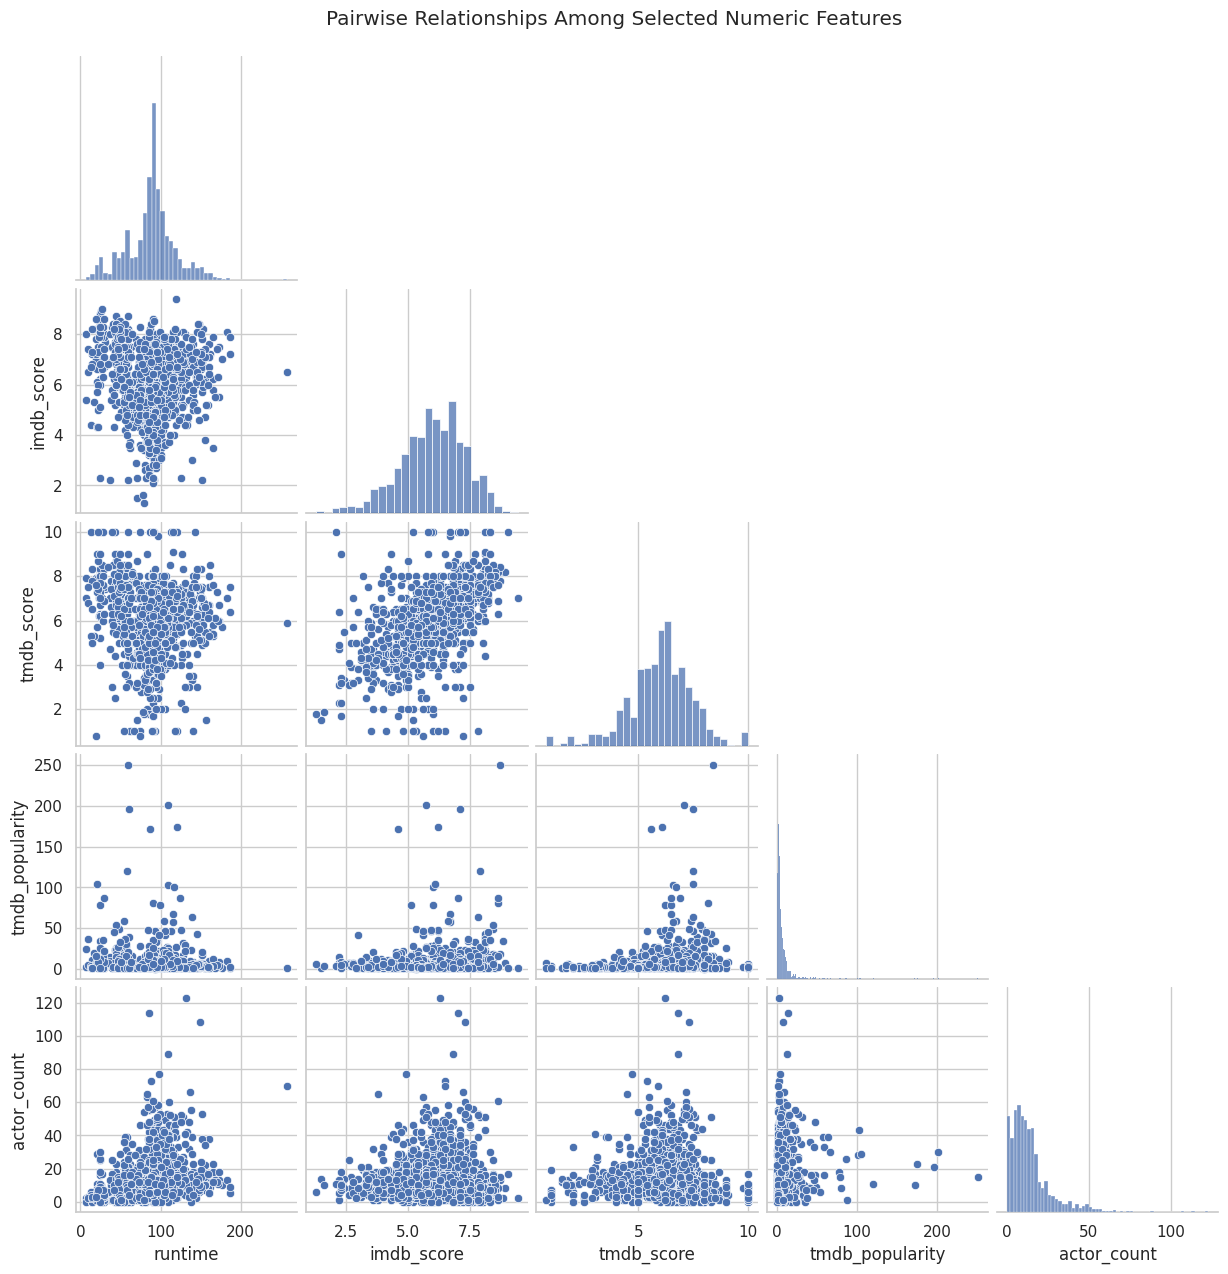

In [21]:
pair_cols=["runtime","imdb_score","tmdb_score","tmdb_popularity","actor_count"]
pair_sample=df[pair_cols].dropna().sample(min(1200, df[pair_cols].dropna().shape[0]), random_state=RANDOM_STATE)
sns.pairplot(pair_sample, corner=True, diag_kind="hist")
plt.suptitle("Pairwise Relationships Among Selected Numeric Features", y=1.02)
plt.show()

**Why this chart?** A pair plot combines distributions and pairwise scatter plots, making nonlinear patterns and outliers easier to inspect.

**How to interpret it:** Use the plotted distributions/relationships rather than assuming correlation implies causation. Outliers and missing-value patterns should also be considered.

## 4A. Additional Visualization Gallery — Go Deeper

### Release year × content type

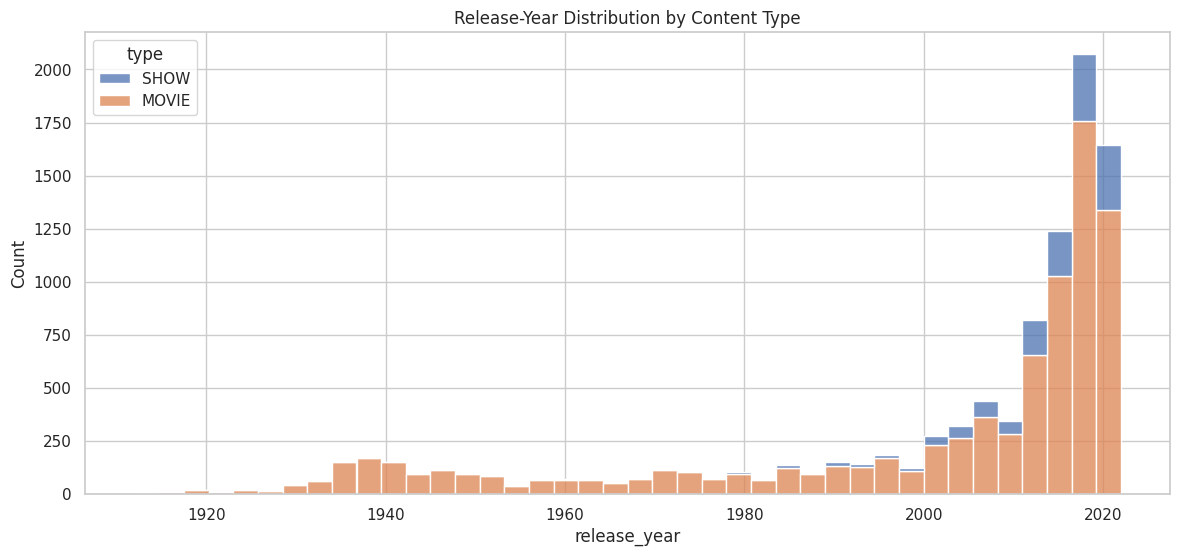

In [22]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x="release_year", hue="type", bins=40, multiple="stack")
plt.title("Release-Year Distribution by Content Type")
plt.show()

### Age certification composition

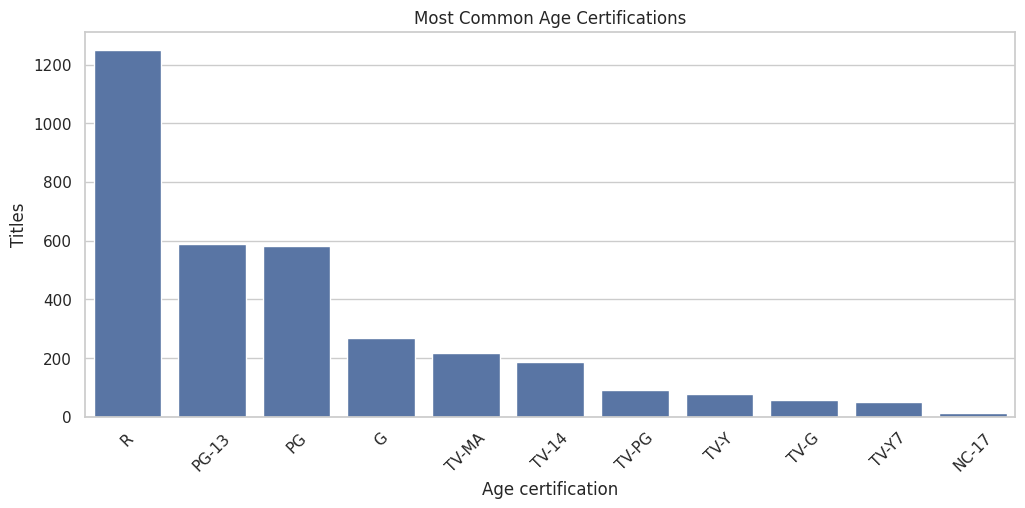

In [23]:
plt.figure(figsize=(12,5))
order=df["age_certification"].value_counts().head(12).index
sns.countplot(data=df, x="age_certification", order=order)
plt.title("Most Common Age Certifications")
plt.xlabel("Age certification"); plt.ylabel("Titles")
plt.xticks(rotation=45); plt.show()

### IMDb score by decade

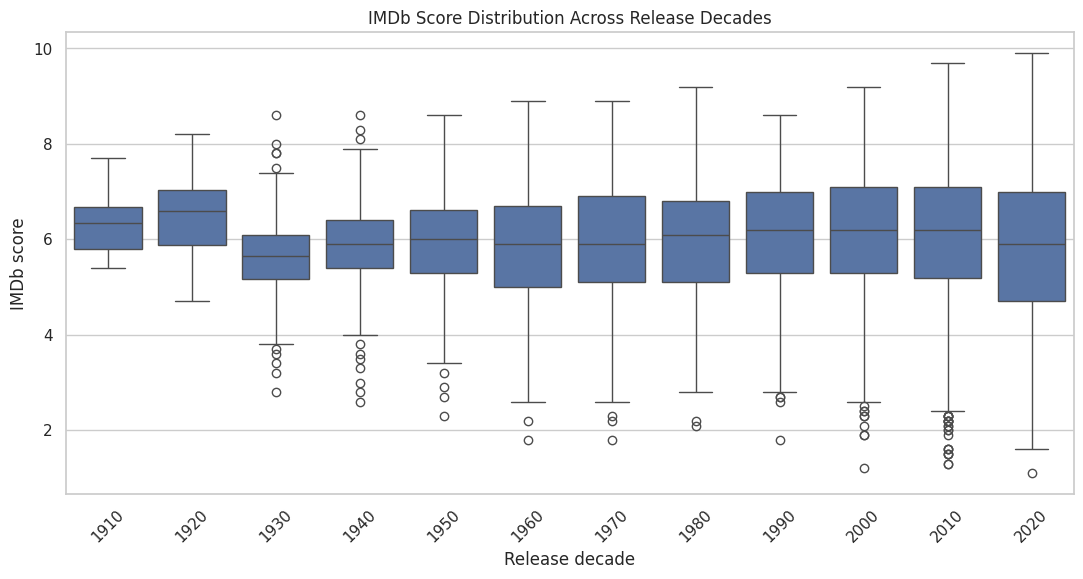

In [24]:
tmp=df.dropna(subset=["imdb_score","release_decade"])
plt.figure(figsize=(13,6))
sns.boxplot(data=tmp, x="release_decade", y="imdb_score")
plt.title("IMDb Score Distribution Across Release Decades")
plt.xlabel("Release decade"); plt.ylabel("IMDb score")
plt.xticks(rotation=45); plt.show()

### Credit structure

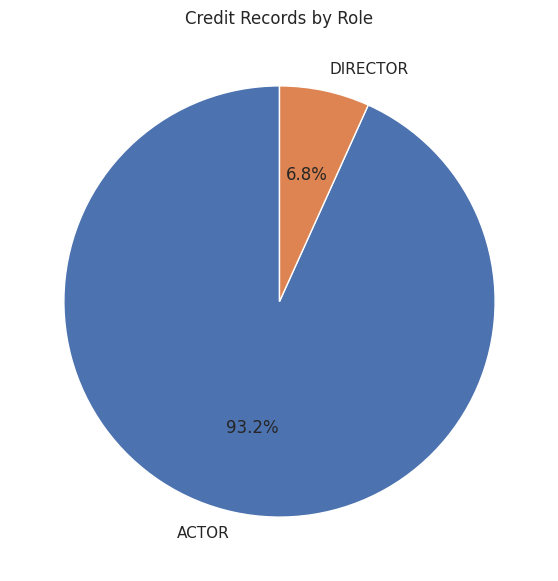

In [25]:
credit_role=credits["role"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(credit_role.values, labels=credit_role.index, autopct="%1.1f%%", startangle=90)
plt.title("Credit Records by Role")
plt.show()

### Director count distribution

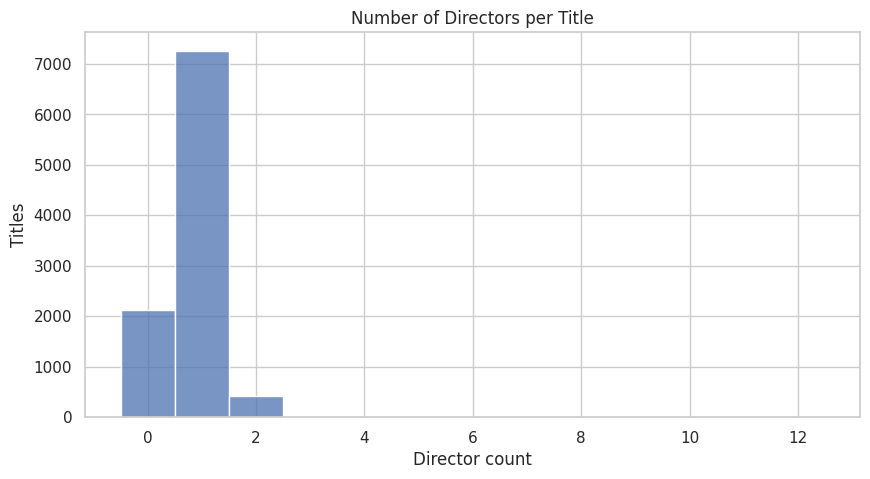

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df["director_count"], bins=20, discrete=True)
plt.title("Number of Directors per Title")
plt.xlabel("Director count"); plt.ylabel("Titles")
plt.show()

### Actor count distribution

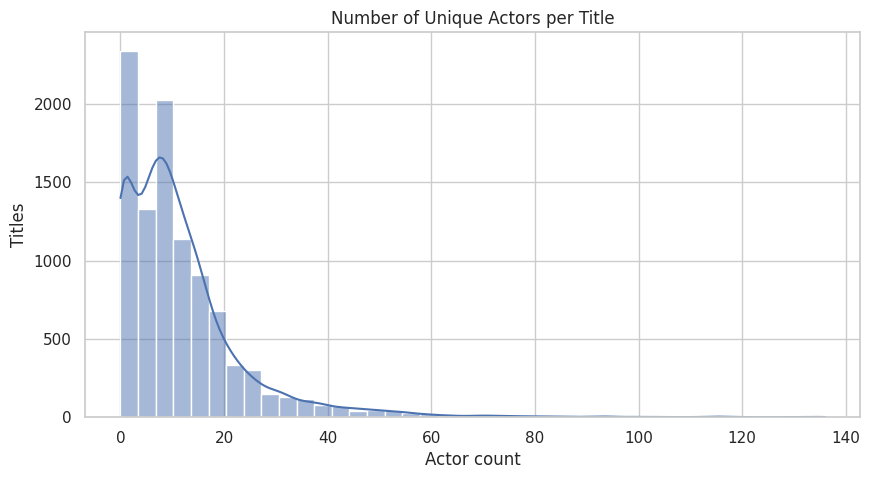

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df["actor_count"], bins=40, kde=True)
plt.title("Number of Unique Actors per Title")
plt.xlabel("Actor count"); plt.ylabel("Titles")
plt.show()

### Runtime vs score by type

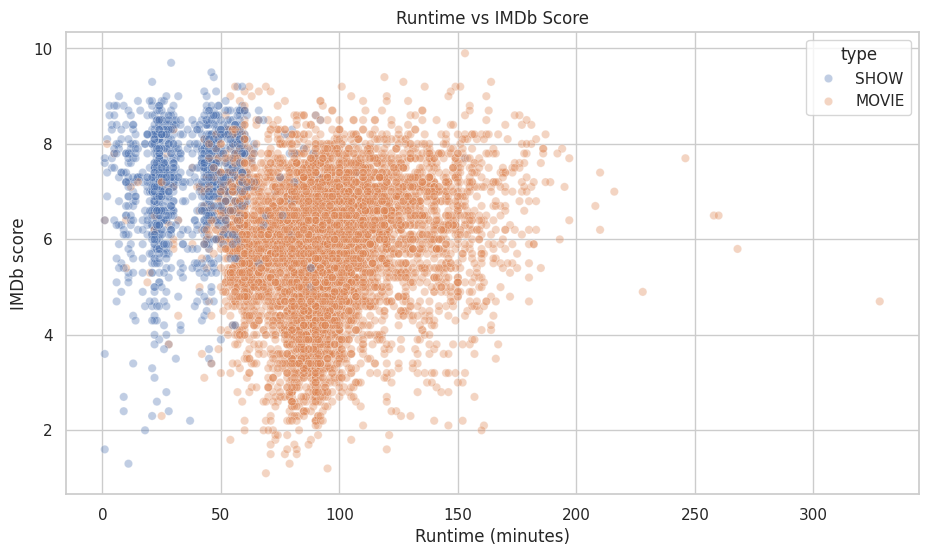

In [28]:
tmp=df.dropna(subset=["runtime","imdb_score"])
plt.figure(figsize=(11,6))
sns.scatterplot(data=tmp, x="runtime", y="imdb_score", hue="type", alpha=0.35)
plt.title("Runtime vs IMDb Score")
plt.xlabel("Runtime (minutes)"); plt.ylabel("IMDb score")
plt.show()

### Popularity distribution

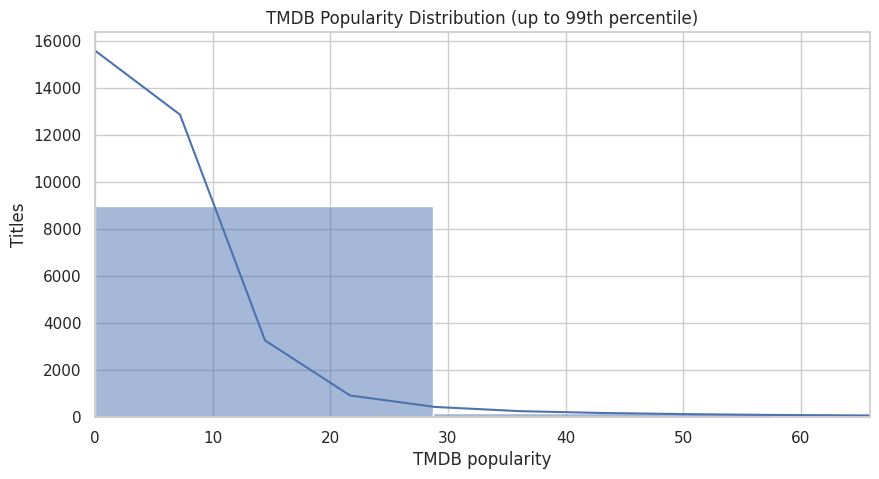

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(df["tmdb_popularity"].dropna(), bins=50, kde=True)
plt.xlim(0, df["tmdb_popularity"].quantile(.99))
plt.title("TMDB Popularity Distribution (up to 99th percentile)")
plt.xlabel("TMDB popularity"); plt.ylabel("Titles")
plt.show()

## 5. Hypothesis Testing

The following tests are selected from relationships visible in the EDA. The goal is to quantify whether observed differences are statistically detectable; statistical significance does not by itself establish practical importance or causality.

In [30]:
# Hypothesis 1: Movies and shows have different IMDb score distributions
movie_scores=df.loc[(df["type"]=="MOVIE") & df["imdb_score"].notna(),"imdb_score"]
show_scores=df.loc[(df["type"]=="SHOW") & df["imdb_score"].notna(),"imdb_score"]

t_stat, p_val = stats.ttest_ind(movie_scores, show_scores, equal_var=False)
print("H0: Mean IMDb score is equal for movies and shows.")
print("H1: Mean IMDb score differs between movies and shows.")
print(f"Movie mean={movie_scores.mean():.3f}, Show mean={show_scores.mean():.3f}")
print(f"Welch t-statistic={t_stat:.3f}, p-value={p_val:.6g}")


H0: Mean IMDb score is equal for movies and shows.
H1: Mean IMDb score differs between movies and shows.
Movie mean=5.803, Show mean=7.118
Welch t-statistic=-35.333, p-value=2.83796e-203


In [31]:
# Hypothesis 2: IMDb and TMDB scores are positively associated
tmp=df.dropna(subset=["imdb_score","tmdb_score"])
r, p = stats.pearsonr(tmp["imdb_score"], tmp["tmdb_score"])
print("H0: Pearson correlation between IMDb and TMDB score is 0.")
print("H1: Pearson correlation is not 0.")
print(f"r={r:.4f}, p-value={p:.6g}")


H0: Pearson correlation between IMDb and TMDB score is 0.
H1: Pearson correlation is not 0.
r=0.5810, p-value=0


In [32]:
# Hypothesis 3: Runtime is associated with IMDb score
tmp=df.dropna(subset=["runtime","imdb_score"])
rho, p = stats.spearmanr(tmp["runtime"], tmp["imdb_score"])
print("H0: Spearman association between runtime and IMDb score is 0.")
print("H1: Spearman association differs from 0.")
print(f"Spearman rho={rho:.4f}, p-value={p:.6g}")


H0: Spearman association between runtime and IMDb score is 0.
H1: Spearman association differs from 0.
Spearman rho=-0.0745, p-value=2.30765e-12


## 6. Feature Engineering & Data Pre-processing

In [33]:
# Create model-ready categorical features from list columns.
TOP_GENRES = genre_counts.head(12).index.tolist()
TOP_COUNTRIES = country_counts.head(10).index.tolist()

model_df = df.copy()

for g in TOP_GENRES:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", g).strip("_")
    model_df[f"genre__{safe}"] = model_df["genres_list"].apply(lambda x: int(g in x))

for ctry in TOP_COUNTRIES:
    safe = re.sub(r"[^a-zA-Z0-9]+", "_", ctry).strip("_")
    model_df[f"country__{safe}"] = model_df["production_countries_list"].apply(lambda x: int(ctry in x))

# Target: IMDb score
model_df = model_df.dropna(subset=["imdb_score"]).copy()

numeric_features = [
    "release_year", "runtime", "seasons", "imdb_votes", "tmdb_popularity",
    "tmdb_score", "total_credits", "actor_count", "director_count", "unique_people",
    "vote_log", "popularity_log"
]
categorical_features = ["type", "age_certification"] + [
    c for c in model_df.columns if c.startswith("genre__") or c.startswith("country__")
]

X = model_df[numeric_features + categorical_features]
y = model_df["imdb_score"]

print("Model rows:", len(model_df))
print("Feature count:", X.shape[1])
print("Target summary:")
display(y.describe())


Model rows: 8850
Feature count: 36
Target summary:


count    8850.000000
mean        5.976395
std         1.343842
min         1.100000
25%         5.100000
50%         6.100000
75%         6.900000
max         9.900000
Name: imdb_score, dtype: float64

### Missing values

Numerical variables are median-imputed because the median is less sensitive to extreme popularity/vote values. Categorical variables use the most frequent category. This preprocessing is placed inside a scikit-learn pipeline so that imputation and encoding are learned from the training data rather than leaking information from the test set.

In [34]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (7080, 36)
Test set: (1770, 36)


### Outlier handling

The notebook keeps real-world outliers such as highly popular titles rather than blindly deleting them. Log-transformed versions of votes and popularity are used to reduce extreme scale effects. Tree-based models are also naturally less sensitive to monotonic scaling and extreme values than many linear approaches.

## 7. ML Model Implementation

In [35]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, pred


models = {
    
    # 1. Ridge Regression
    "Ridge Regression": Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]),

    # 2. Random Forest
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=350,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    # 3. Gradient Boosting
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ))
    ]),

    # 4. XGBoost
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}


# Train and evaluate all models
results = []
predictions = {}

for name, model in models.items():
    row, pred = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(row)
    predictions[name] = pred


# Model comparison
results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)

,Model,MAE,RMSE,R2
0,XGBoost,0.628180,0.877065,0.573065
1,Gradient Boosting,0.654236,0.895927,0.554504
2,Random Forest,0.655180,0.909733,0.540669
3,Ridge Regression,0.744070,1.000354,0.444600


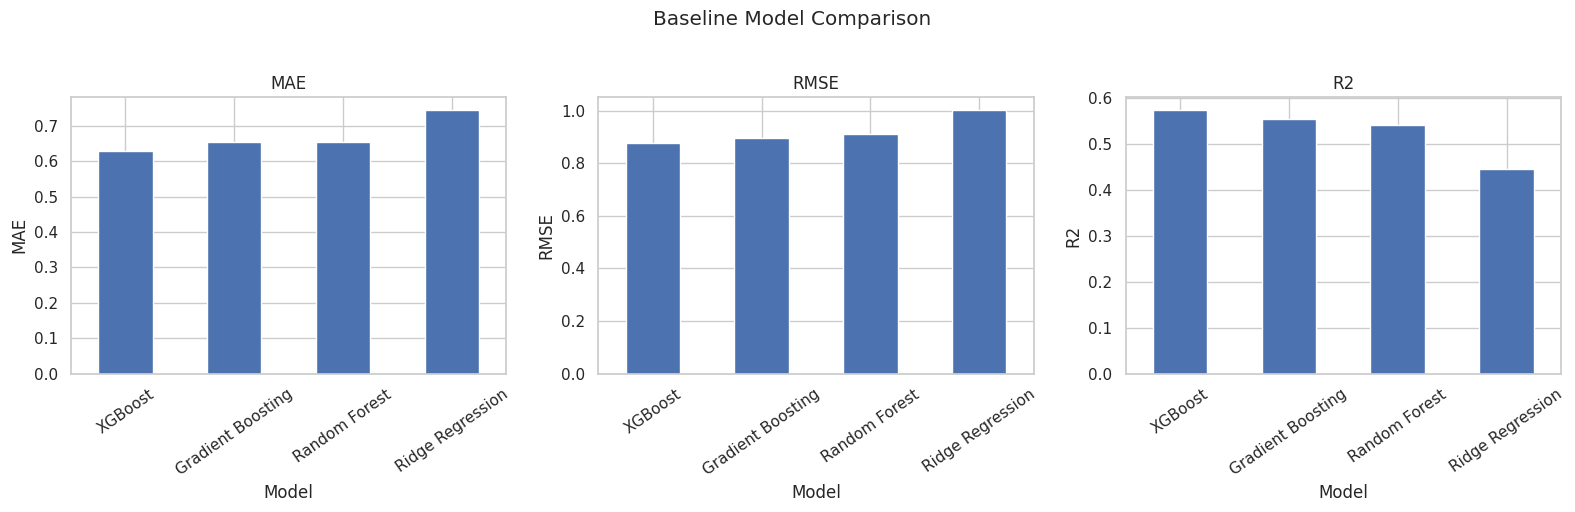

In [36]:
# Model evaluation score chart
plot_df=results_df.set_index("Model")[["MAE","RMSE","R2"]]
fig, axes=plt.subplots(1,3,figsize=(16,5))
for ax, metric in zip(axes, ["MAE","RMSE","R2"]):
    plot_df[metric].sort_values(ascending=(metric!="R2")).plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)
plt.suptitle("Baseline Model Comparison", y=1.02)
plt.tight_layout()
plt.show()


### Cross-validation

Five-fold cross-validation provides a more stable estimate of model performance than a single train/test split. RMSE is used for the main comparison because it penalizes larger prediction errors more strongly, while MAE remains easy to interpret in IMDb-score points.

,Model,CV_RMSE_Mean,CV_RMSE_STD
3,XGBoost,0.871393,0.018269
1,Random Forest,0.886133,0.015277
2,Gradient Boosting,0.893926,0.020609
0,Ridge Regression,0.989816,0.019847


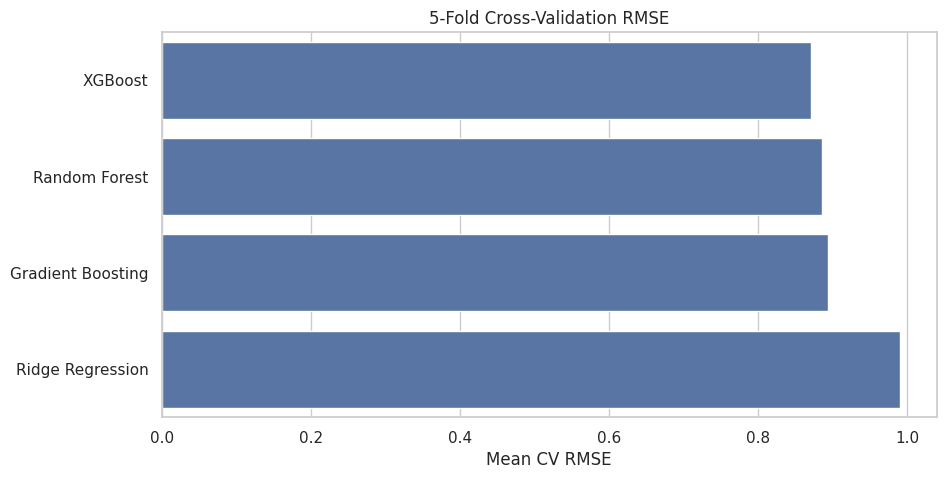

In [37]:
cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows=[]
for name, model in models.items():
    scores=-cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_rows.append({"Model":name, "CV_RMSE_Mean":scores.mean(), "CV_RMSE_STD":scores.std()})
cv_df=pd.DataFrame(cv_rows).sort_values("CV_RMSE_Mean")
display(cv_df)

plt.figure(figsize=(10,5))
sns.barplot(data=cv_df, x="CV_RMSE_Mean", y="Model")
plt.title("5-Fold Cross-Validation RMSE")
plt.xlabel("Mean CV RMSE"); plt.ylabel("")
plt.show()


## Hyperparameter Tuning — Random Forest

Randomized search could be used for very large parameter spaces. Here, a compact grid is sufficient and easier to reproduce. The tuning objective is negative RMSE, so lower RMSE after converting the sign is better.

In [38]:
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = {
    "model__n_estimators": [250, 450],
    "model__max_depth": [12, 18, None],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    rf_pipeline, rf_grid, cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("Best parameters:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)
print("Test MAE:", mean_absolute_error(y_test, best_rf_pred))
test_mse = mean_squared_error(y_test, best_rf_pred)
test_rmse = np.sqrt(test_mse)

print("Test RMSE:", test_rmse)
print("Test R²:", r2_score(y_test, best_rf_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 450}
Best CV RMSE: 0.8908335945784653
Test MAE: 0.6544836530858948
Test RMSE: 0.9090555477392864
Test R²: 0.5413523066237274


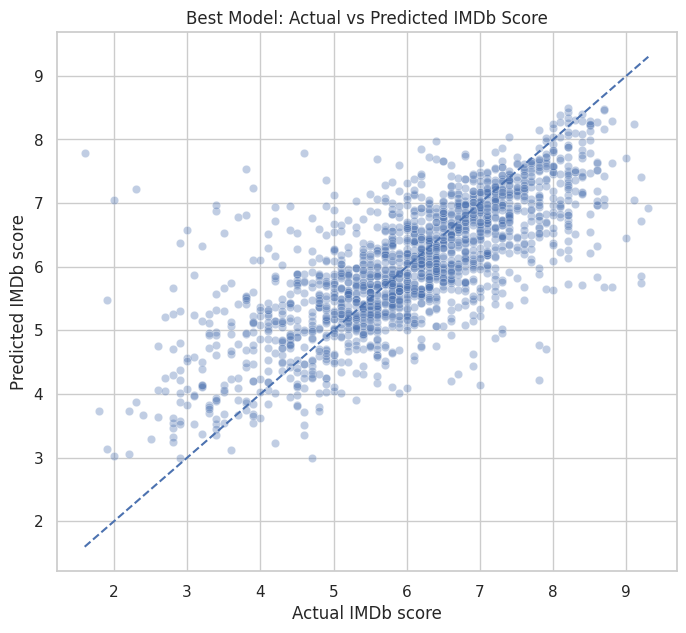

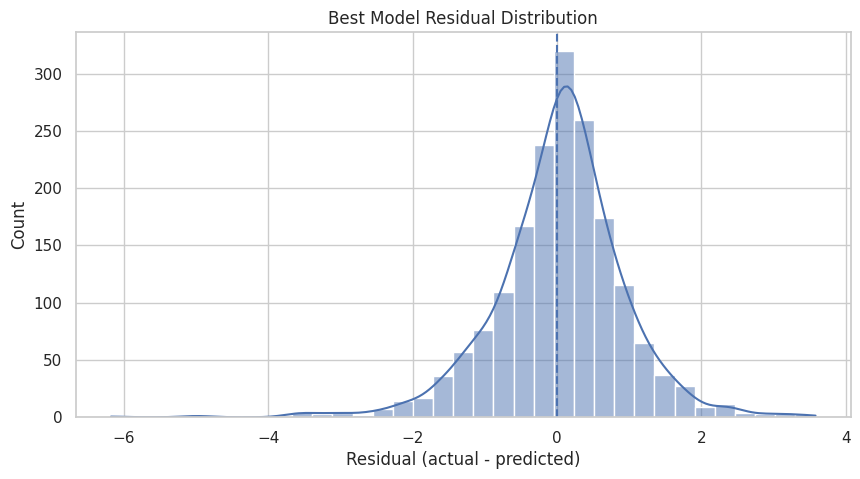

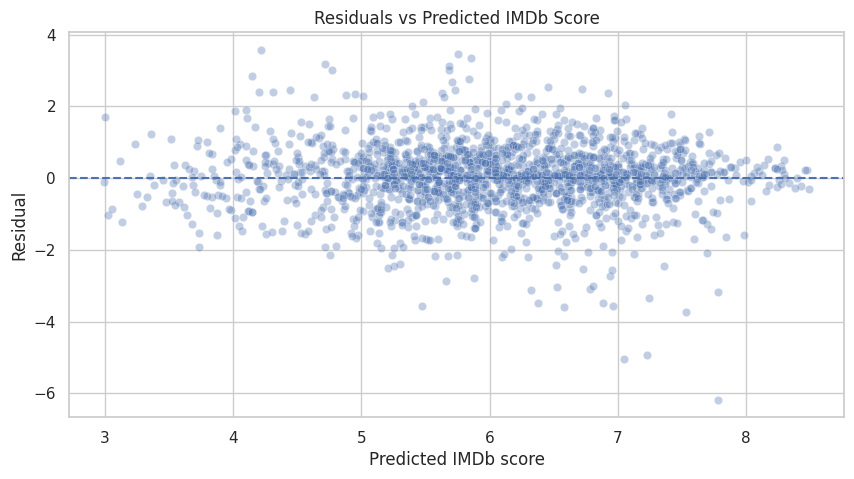

In [39]:
# Actual vs predicted
plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=best_rf_pred, alpha=0.35)
lims=[min(y_test.min(), best_rf_pred.min()), max(y_test.max(), best_rf_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.title("Best Model: Actual vs Predicted IMDb Score")
plt.xlabel("Actual IMDb score"); plt.ylabel("Predicted IMDb score")
plt.show()

# Residual distribution
residuals=y_test.to_numpy()-best_rf_pred
plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=35, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Best Model Residual Distribution")
plt.xlabel("Residual (actual - predicted)"); plt.ylabel("Count")
plt.show()

# Residuals vs predictions
plt.figure(figsize=(10,5))
sns.scatterplot(x=best_rf_pred, y=residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted IMDb Score")
plt.xlabel("Predicted IMDb score"); plt.ylabel("Residual")
plt.show()


## Model Explainability — Permutation Importance

Permutation importance measures how much model performance deteriorates when a feature column is randomly shuffled. It is computed on the held-out test set here, which makes the importance estimate directly tied to unseen-data performance. It should be interpreted as predictive importance, not causality.

,feature,importance_mean,importance_std
5,tmdb_score,0.445438,0.020723
21,genre__horror,0.063304,0.005675
3,imdb_votes,0.058604,0.004868
10,vote_log,0.055397,0.004430
20,genre__documentation,0.048513,0.004163
0,release_year,0.036072,0.004109
1,runtime,0.026796,0.004081
17,genre__action,0.018254,0.003218
12,type,0.015829,0.002252
7,actor_count,0.012645,0.003420


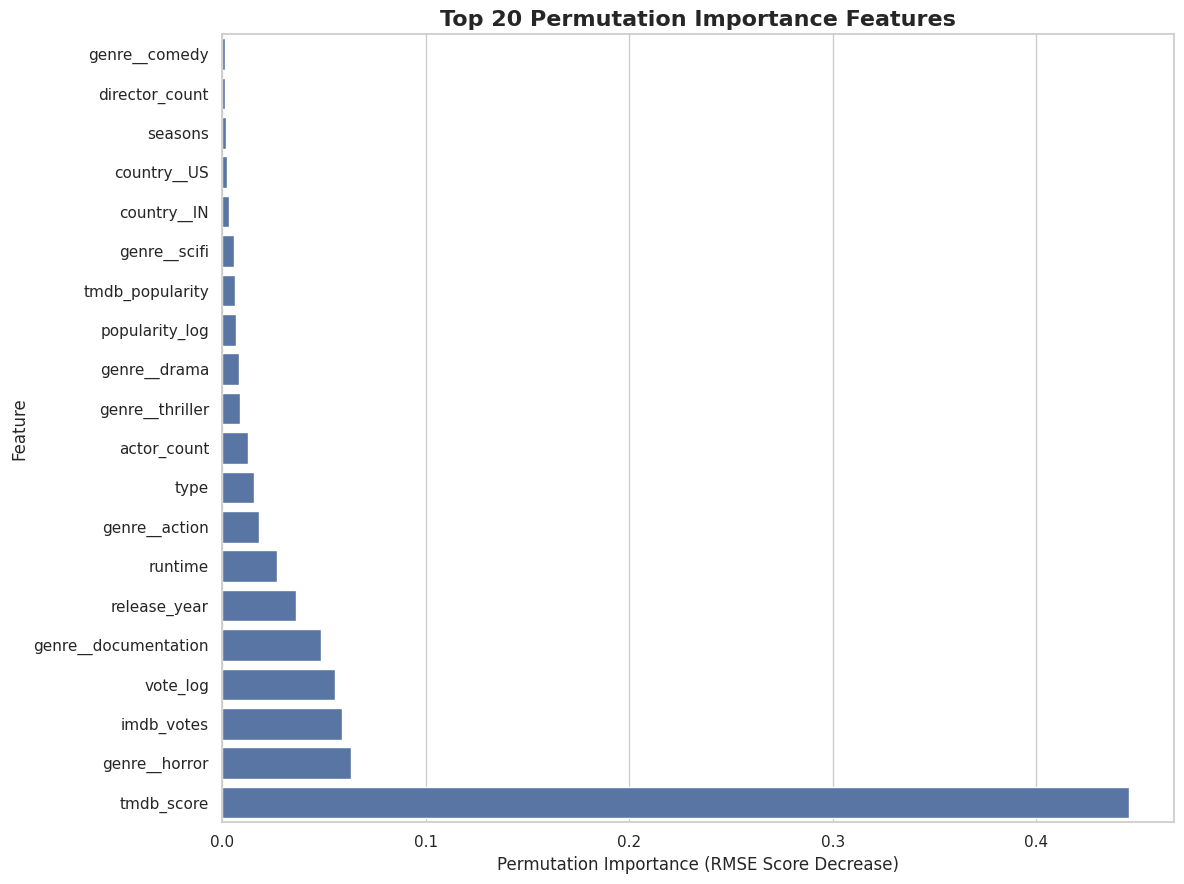

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# Permutation Importance on the complete pipeline
# ---------------------------------------------------------
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# IMPORTANT:
# Since permutation_importance was applied to the complete
# pipeline, importance values correspond to ORIGINAL X_test
# columns, not one-hot encoded columns.
feature_names = X_test.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

# Top 20 features
importance_top20 = importance_df.head(20)

display(importance_top20)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12, 9))

plot_df = importance_top20.sort_values(
    "importance_mean",
    ascending=True
)

sns.barplot(
    data=plot_df,
    x="importance_mean",
    y="feature"
)

plt.title(
    "Top 20 Permutation Importance Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Permutation Importance (RMSE Score Decrease)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Error Analysis — Where Does the Model Struggle?

Largest absolute errors:


,id,title,type,release_year,imdb_score,predicted_score,absolute_error
6464,ts105811,Pinkfong! Baby Shark,SHOW,2017,1.6,7.780240,6.180240
8765,ts259788,The Carlos Watson Show,SHOW,2020,2.0,7.050478,5.050478
6840,tm443248,Rebirth,MOVIE,2018,2.3,7.229339,4.929339
6641,tm521388,Over There,MOVIE,2017,3.8,7.530053,3.730053
8859,tm829107,Captain Rana Prathap,MOVIE,2019,3.0,6.580656,3.580656
3188,tm129612,The Howlin' Wolf Story: The Secret History of Rock & Roll,MOVIE,2003,7.8,4.220140,3.579860
7344,tm233133,English Padam,MOVIE,2017,1.9,5.470700,3.570700
3177,ts8597,Fear Factor,SHOW,2002,3.4,6.964918,3.564918
6098,tm531702,The Refractor,MOVIE,2016,3.4,6.882201,3.482201
7981,tm454024,The Pit,MOVIE,2019,2.9,6.375865,3.475865


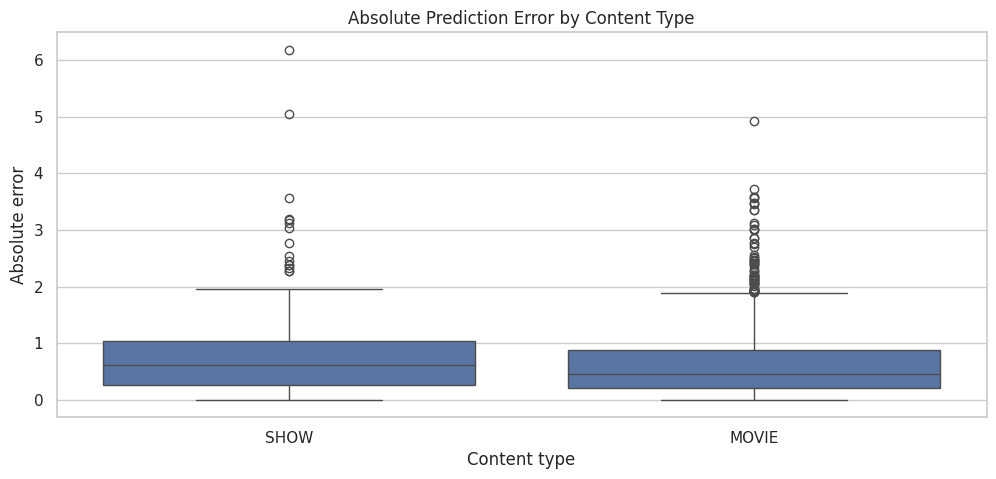

In [41]:
error_df=model_df.loc[X_test.index, ["id","title","type","release_year","imdb_score"]].copy()
error_df["predicted_score"]=best_rf_pred
error_df["absolute_error"]=np.abs(error_df["imdb_score"]-error_df["predicted_score"])

print("Largest absolute errors:")
display(error_df.sort_values("absolute_error", ascending=False).head(20))

plt.figure(figsize=(12,5))
sns.boxplot(data=error_df, x="type", y="absolute_error")
plt.title("Absolute Prediction Error by Content Type")
plt.xlabel("Content type"); plt.ylabel("Absolute error")
plt.show()


## Feature Importance / Model Interpretation

The model should be interpreted as a predictive system. Features with high permutation importance are useful for estimating IMDb score in this dataset, but this does not mean changing those features would cause the score to change. In particular, external rating/popularity variables can be strong predictors because they summarize audience behavior and platform-level signals.

## 8. Future Work & Deployment

In [42]:
# Save the tuned model for deployment
import joblib

model_filename = "amazon_prime_imdb_score_model.joblib"
joblib.dump(best_rf, model_filename)
print("Saved:", model_filename)


Saved: amazon_prime_imdb_score_model.joblib


In [43]:
# Reload and sanity-check on unseen test records
loaded_model = joblib.load(model_filename)
sanity_pred = loaded_model.predict(X_test.head(10))

sanity_check = X_test.head(10).copy()
sanity_check["actual_imdb_score"] = y_test.head(10).values
sanity_check["predicted_imdb_score"] = np.round(sanity_pred, 3)
display(sanity_check[["type","release_year","runtime","actual_imdb_score","predicted_imdb_score"]])


,type,release_year,runtime,actual_imdb_score,predicted_imdb_score
7449,SHOW,2019,33,8.4,8.297
3887,MOVIE,2005,97,5.5,5.005
4659,MOVIE,2014,98,6.2,6.114
9830,MOVIE,2021,104,5.4,6.172
4738,MOVIE,2014,103,5.7,6.185
5704,MOVIE,2015,73,3.5,3.687
854,MOVIE,1935,59,6.0,5.344
2574,MOVIE,1999,96,5.5,6.014
1104,MOVIE,1973,87,5.5,5.306
9693,MOVIE,2021,98,4.9,5.222


## Final Business Findings

- The catalog contains both movies and TV shows, with different distributions across runtime, release periods and ratings.
- Genre and country expansion reveals which categories and markets are most represented.
- IMDb score has measurable relationships with other rating/popularity variables, but correlation should not be interpreted as causation.
- Aggregated credit features convert the person-level credits table into useful title-level signals.
- The regression comparison and cross-validation provide a reproducible basis for selecting a predictive approach.
- Residual and error analysis identifies where predictions are less reliable instead of relying on a single headline metric.
- The saved pipeline includes preprocessing and the tuned estimator, making it suitable as a starting point for deployment.


# Conclusion

This notebook combines extensive EDA with a complete machine-learning workflow on the merged Amazon Prime titles and credits data. It covers data quality, merging, feature engineering, statistical testing, visualization, model comparison, cross-validation, hyperparameter tuning, residual analysis, permutation-based explainability and model persistence.

The strongest practical next step would be to validate the model on a temporally separated test set or on a newer catalog snapshot. That would better simulate the real deployment scenario in which the model predicts ratings for future titles rather than randomly sampled historical titles.
